# 🔍 Notebook 06 — Feature Importance & Final Report
**Chicago Crime ML Pipeline — Final Notebook**

This notebook closes the pipeline with:

| Section | Content |
|---|---|
| Feature Importance | Tree-based importance + Permutation importance for all 3 tasks |
| SHAP Analysis | SHAP summary & waterfall plots for best models |
| Learning Curves | Bias-variance diagnosis per task |
| Error Analysis | Where and why models fail |
| Final Report | Printed + CSV summary of the entire pipeline |

> ✅ This is the **last notebook** in the Chicago Crime ML Pipeline.

---
## 1. Imports & Config

In [2]:
import sys, types, sklearn, numpy as np
print(f'sklearn version: {sklearn.__version__}')

from packaging.version import Version

if Version(sklearn.__version__) >= Version('1.3'):
    # sklearn 1.3+ — loss classes live in sklearn._loss.loss
    from sklearn._loss import loss as _loss_src
    _NAME_MAP = {
        'BinaryCrossEntropy'     : 'HalfBinomialLoss',
        'CategoricalCrossEntropy': 'HalfMultinomialLoss',
        'LeastSquares'           : 'HalfSquaredError',
        'LeastAbsoluteDeviation' : 'AbsoluteError',
        'Poisson'                : 'HalfPoissonLoss',
        'Gamma'                  : 'HalfGammaLoss',
        'Quantile'               : 'PinballLoss',
    }
    def _make_shim(fake_path, real_module, name_map=None):
        shim = types.ModuleType(fake_path)
        for name in dir(real_module):
            setattr(shim, name, getattr(real_module, name))
        if name_map:
            for old, new in name_map.items():
                if hasattr(real_module, new):
                    setattr(shim, old, getattr(real_module, new))
        sys.modules[fake_path] = shim
    _make_shim('sklearn.ensemble._hist_gradient_boosting.loss',  _loss_src, _NAME_MAP)
    _make_shim('sklearn.ensemble._hist_gradient_boosting._loss', _loss_src, _NAME_MAP)
    print('sklearn 1.3+ shims installed ✅')

elif Version(sklearn.__version__) >= Version('1.0'):
    # sklearn 1.0–1.2 — loss classes moved inside the ensemble subpackage
    from sklearn.ensemble._hist_gradient_boosting import _loss as _loss_src
    def _make_shim(fake_path, real_module):
        shim = types.ModuleType(fake_path)
        for name in dir(real_module):
            setattr(shim, name, getattr(real_module, name))
        sys.modules[fake_path] = shim
    _make_shim('sklearn.ensemble._hist_gradient_boosting.loss', _loss_src)
    print('sklearn 1.0–1.2 shims installed ✅')

else:
    # sklearn < 1.0 — original module paths still exist, no shim needed
    print(f'sklearn {sklearn.__version__} — no shim needed ✅')


sklearn version: 0.24.2
sklearn 0.24.2 — no shim needed ✅


In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, json, joblib

from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_squared_error, r2_score
)

# SHAP (optional but recommended)
try:
    import shap
    HAS_SHAP = True
    print('SHAP found ✅')
except ImportError:
    HAS_SHAP = False
    print('⚠️  SHAP not installed. Run: pip install shap')
    print('   Tree-based + permutation importance will still run.')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR  = 'ml_data'
MODEL_DIR = 'ml_models'
RANDOM_STATE = 42
TOP_N_FEATURES = 20

print('Setup complete ✅')

SHAP found ✅
Setup complete ✅


---
## 2. Load Data, Models & Metadata

In [5]:
# ⚡ Config guard — ensures variables are defined even if cells run out of order
DATA_DIR     = globals().get('DATA_DIR',  'ml_data')
MODEL_DIR    = globals().get('MODEL_DIR', 'ml_models')
RANDOM_STATE = globals().get('RANDOM_STATE', 42)
TOP_N_FEATURES = globals().get('TOP_N_FEATURES', 20)

def load_task(task_name):
    data = np.load(f'{DATA_DIR}/{task_name}_preprocessed.npz', allow_pickle=True)
    with open(f'{DATA_DIR}/{task_name}_meta.json') as f:
        meta = json.load(f)
    return (data['X_train'], data['X_val'], data['X_test'],
            data['y_train'], data['y_val'], data['y_test'], meta)

X_tr1, X_v1, X_te1, y_tr1, y_v1, y_te1, meta1 = load_task('task1')
X_tr2, X_v2, X_te2, y_tr2, y_v2, y_te2, meta2 = load_task('task2')
X_tr3, X_v3, X_te3, y_tr3, y_v3, y_te3, meta3 = load_task('task3')

best_m1 = joblib.load(f'{MODEL_DIR}/task1_best_model.pkl')
best_m2 = joblib.load(f'{MODEL_DIR}/task2_best_model.pkl')
best_m3 = joblib.load(f'{MODEL_DIR}/task3_best_model.pkl')

# ════════════════════════════════════════════════════════════════════════════
# MODEL PATCH — version-aware, only patches when loading old pkl on new sklearn
# ════════════════════════════════════════════════════════════════════════════
from packaging.version import Version as _V
_skv = _V(sklearn.__version__)

if _skv >= _V('1.3'):
    from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
    from sklearn._loss import loss as _loss_module
    _LOSS_REMAP = {
        'LeastSquares'           : 'HalfSquaredError',
        'BinaryCrossEntropy'     : 'HalfBinomialLoss',
        'CategoricalCrossEntropy': 'HalfMultinomialLoss',
        'LeastAbsoluteDeviation' : 'AbsoluteError',
        'Poisson'                : 'HalfPoissonLoss',
        'Gamma'                  : 'HalfGammaLoss',
        'Quantile'               : 'PinballLoss',
    }
    def _patch_hgb(model):
        if not isinstance(model, (HistGradientBoostingClassifier, HistGradientBoostingRegressor)):
            return model
        for attr, default in [('_preprocessor', None), ('_is_fitted', True), ('_no_validation', False)]:
            if not hasattr(model, attr):
                setattr(model, attr, default)
        if hasattr(model, '_baseline_prediction'):
            bp = model._baseline_prediction
            if bp.ndim == 2 and bp.shape[1] == 1 and bp.shape[0] > 1:
                model._baseline_prediction = bp.T
        if hasattr(model, '_loss'):
            old_name = type(model._loss).__name__
            new_name = _LOSS_REMAP.get(old_name, old_name)
            if hasattr(_loss_module, new_name):
                try:
                    new_cls = getattr(_loss_module, new_name)
                    n_classes = getattr(model._loss, 'n_classes', None)
                    model._loss = new_cls(n_classes=n_classes) if n_classes else new_cls()
                except Exception as e:
                    print(f'  ⚠️  Could not replace _loss ({old_name}): {e}')
        return model

elif _skv >= _V('0.21'):
    try:
        from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
    except ImportError:
        from sklearn.experimental import enable_hist_gradient_boosting  # noqa
        from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
    def _patch_hgb(model):
        return model  # same sklearn as when saved — no patch needed

else:
    def _patch_hgb(model):
        return model

best_m1 = _patch_hgb(best_m1)
best_m2 = _patch_hgb(best_m2)
best_m3 = _patch_hgb(best_m3)
print(f'Models patched for sklearn {sklearn.__version__} ✅')
# ════════════════════════════════════════════════════════════════════════════

feat1 = meta1['feature_names']
feat2 = meta2['feature_names']
feat3 = meta3['feature_names']

with open(f'{DATA_DIR}/task2_label_map.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in sorted(label_map.keys(), key=int)]

with open(f'{MODEL_DIR}/training_summary.json') as f:
    train_summary = json.load(f)

scorecard = pd.read_csv(f'{DATA_DIR}/05_scorecard.csv')

print('All data, models and metadata loaded ✅')
print(f'  Task 1 features: {len(feat1)}   Task 2: {len(feat2)}   Task 3: {len(feat3)}')


Models patched for sklearn 0.24.2 ✅
All data, models and metadata loaded ✅
  Task 1 features: 23   Task 2: 21   Task 3: 19


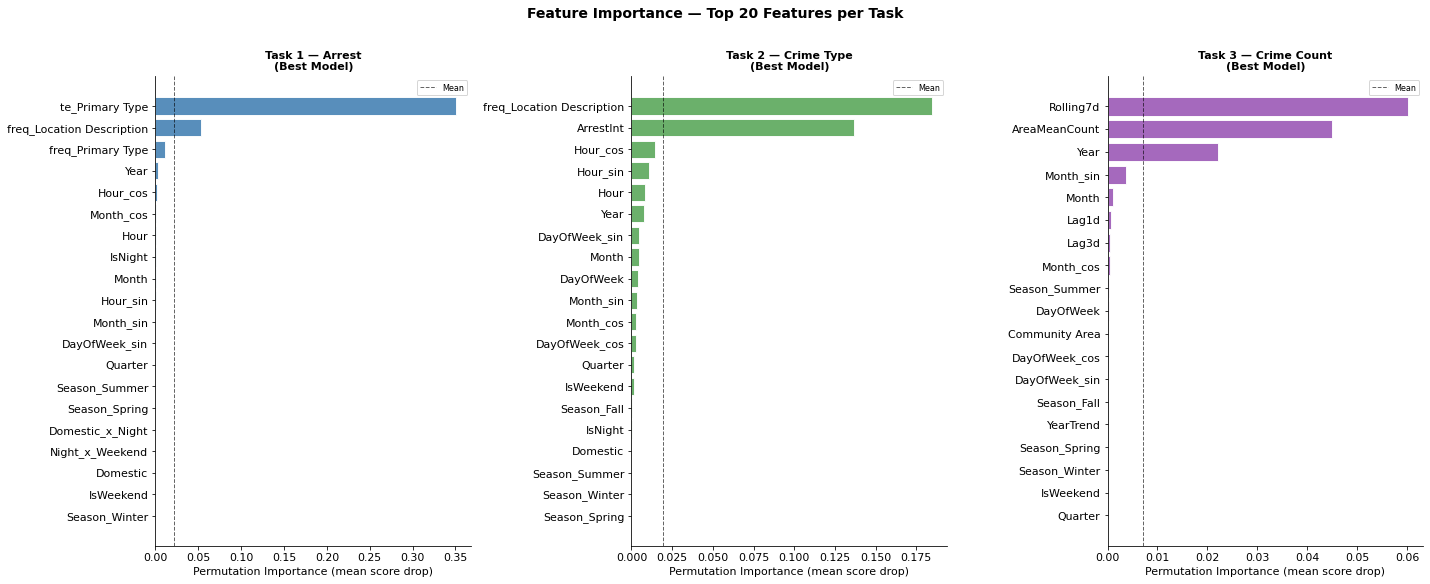

In [24]:
from sklearn.inspection import permutation_importance as _perm_imp
from sklearn.metrics import check_scoring

def plot_tree_importance(model, feature_names, title, color, ax, top_n=TOP_N_FEATURES):
    """Plot feature importances — tries feature_importances_, then coef_,
    then falls back to a fast permutation importance."""

    est = list(model.named_steps.values())[-1] if hasattr(model, 'named_steps') else model

    if hasattr(est, 'feature_importances_'):
        imp = pd.Series(est.feature_importances_, index=feature_names)
        xlabel = 'Feature Importance (Gini / MSE reduction)'

    elif hasattr(est, 'coef_'):
        coef = est.coef_
        if coef.ndim > 1:
            coef = np.abs(coef).mean(axis=0)
        imp = pd.Series(np.abs(coef.ravel()), index=feature_names)
        xlabel = 'Feature Importance (|coefficient|)'

    else:
        ax.text(0.5, 0.5, 'Computing via\npermutation importance...',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.figure.canvas.draw()
        return  # will be filled by permutation importance section below

    imp = imp.sort_values(ascending=True).tail(top_n)
    imp.plot.barh(ax=ax, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xlabel)
    ax.axvline(imp.mean(), color='black', linestyle='--',
               linewidth=1, alpha=0.6, label='Mean')
    ax.legend(fontsize=8)


# ── Use training_summary importances if available, else use permutation results
def plot_from_perm(perm_df, title, color, ax, top_n=TOP_N_FEATURES):
    """Plot from already-computed permutation importance dataframe."""
    plot_df = perm_df.sort_values('mean').tail(top_n)
    ax.barh(plot_df['feature'], plot_df['mean'], color=color, edgecolor='white', alpha=0.9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Permutation Importance (mean score drop)')
    ax.axvline(plot_df['mean'].mean(), color='black', linestyle='--',
               linewidth=1, alpha=0.6, label='Mean')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(20, 8))
configs = [
    (best_m1, feat1, perm1, 'Task 1 — Arrest\n(Best Model)', 'steelblue'),
    (best_m2, feat2, perm2, 'Task 2 — Crime Type\n(Best Model)', '#5ba85b'),
    (best_m3, feat3, perm3, 'Task 3 — Crime Count\n(Best Model)', '#9b59b6'),
]

for ax, (model, feats, perm_df, title, color) in zip(axes, configs):
    est = list(model.named_steps.values())[-1] if hasattr(model, 'named_steps') else model
    if hasattr(est, 'feature_importances_') or hasattr(est, 'coef_'):
        plot_tree_importance(model, feats, title, color, ax)
    else:
        # HGB on old sklearn — use permutation importance instead
        plot_from_perm(perm_df, title, color, ax)

plt.suptitle('Feature Importance — Top 20 Features per Task',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/06_tree_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Permutation Feature Importance
Model-agnostic — works even for Logistic Regression and Ridge.

In [23]:
def compute_permutation_importance(model, X, y, feature_names,
                                   scoring, n_repeats=5, top_n=TOP_N_FEATURES):

    result = permutation_importance(
        model, X, y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    imp = pd.DataFrame({
        'feature': feature_names,
        'mean': result.importances_mean,
        'std': result.importances_std
    }).sort_values('mean', ascending=False).head(top_n)

    return imp

print('Computing permutation importances (this may take a minute)...')
perm1 = compute_permutation_importance(best_m1, X_te1, y_te1, feat1, 'roc_auc')
print('  Task 1 done ')
perm2 = compute_permutation_importance(best_m2, X_te2, y_te2, feat2, 'f1_weighted')
print('  Task 2 done ')
perm3 = compute_permutation_importance(best_m3, X_te3, np.log1p(y_te3), feat3,
                                        'neg_root_mean_squared_error')
perm3['mean'] = perm3['mean'].abs()   # RMSE decrease → higher = more important
print('  Task 3 done ')

Computing permutation importances (this may take a minute)...
  Task 1 done 
  Task 2 done 
  Task 3 done 


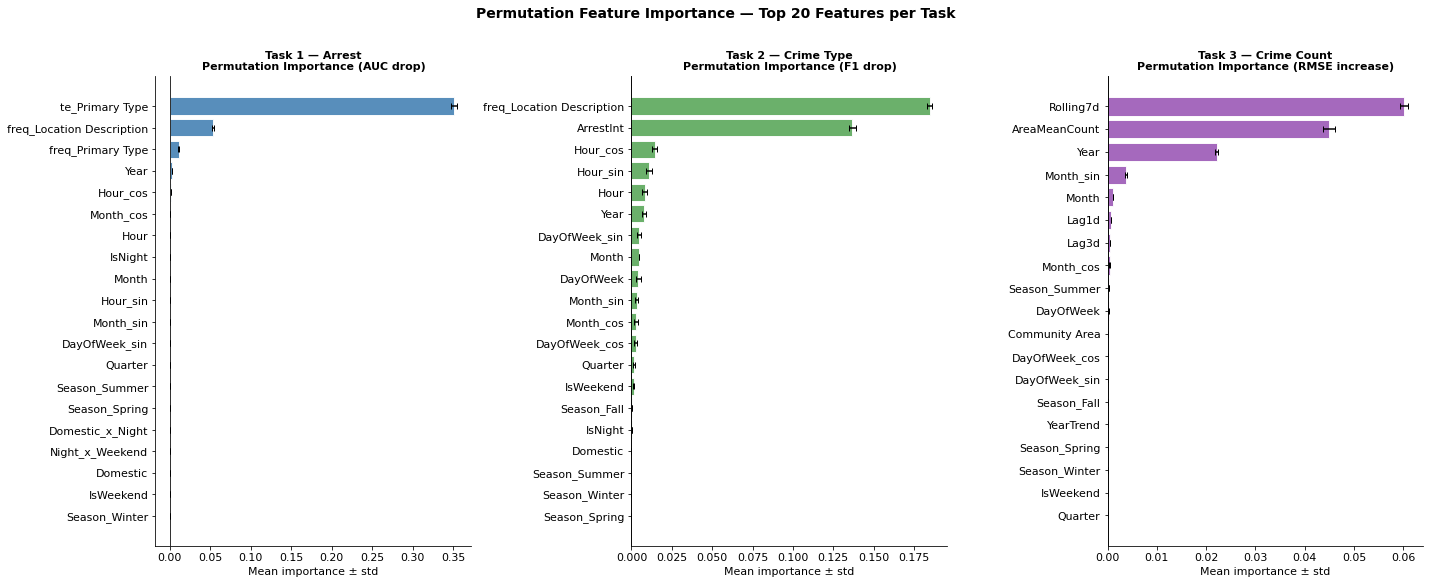

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
perm_configs = [
    (perm1, 'Task 1 — Arrest\nPermutation Importance (AUC drop)', 'steelblue'),
    (perm2, 'Task 2 — Crime Type\nPermutation Importance (F1 drop)', '#5ba85b'),
    (perm3, 'Task 3 — Crime Count\nPermutation Importance (RMSE increase)', '#9b59b6'),
]

for ax, (perm_df, title, color) in zip(axes, perm_configs):
    perm_plot = perm_df.sort_values('mean').tail(TOP_N_FEATURES)
    ax.barh(perm_plot['feature'], perm_plot['mean'],
            xerr=perm_plot['std'], color=color,
            edgecolor='white', alpha=0.9, capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean importance ± std')

plt.suptitle('Permutation Feature Importance — Top 20 Features per Task',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/06_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. SHAP Analysis
Global feature explanations using SHAP values.

  Computing SHAP for Task 1 — Arrest Prediction...


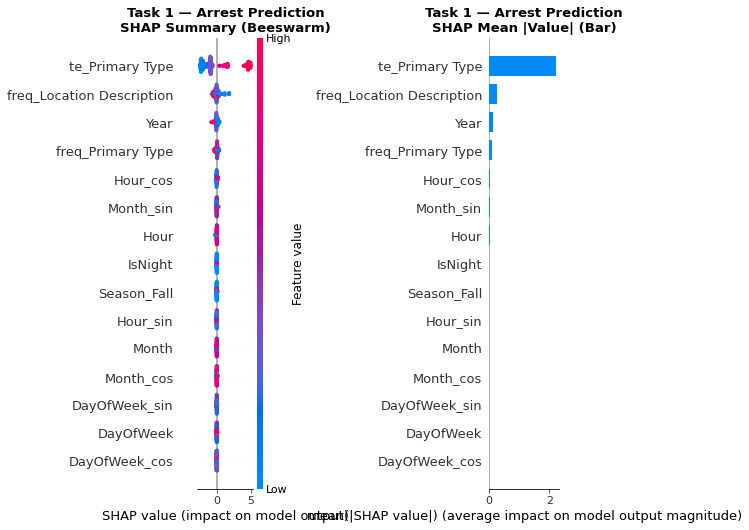

    ✅ SHAP plot saved
  Computing SHAP for Task 2 — Crime Type...


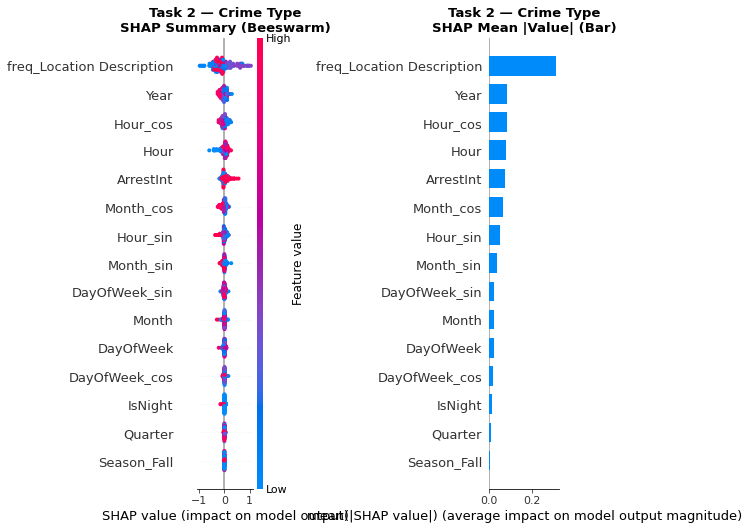

    ✅ SHAP plot saved
  Computing SHAP for Task 3 — Crime Count...


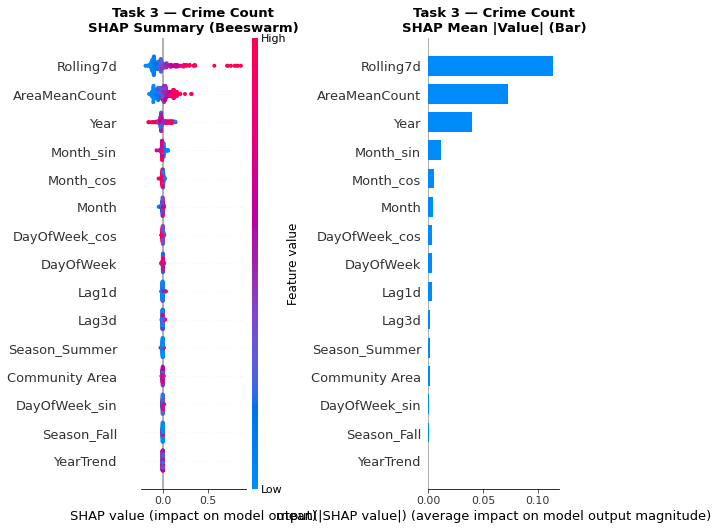

    ✅ SHAP plot saved


In [9]:
if HAS_SHAP:
    # Use a subsample of test set for speed
    SHAP_SAMPLE = 200  #  reduced from 500
    rng = np.random.default_rng(RANDOM_STATE)
    idx1 = rng.choice(len(X_te1), SHAP_SAMPLE, replace=False)
    idx2 = rng.choice(len(X_te2), SHAP_SAMPLE, replace=False)
    idx3 = rng.choice(len(X_te3), SHAP_SAMPLE, replace=False)

    shap_tasks = [
        (best_m1, X_te1[idx1], feat1, 'Task 1 — Arrest Prediction'),
        (best_m2, X_te2[idx2], feat2, 'Task 2 — Crime Type'),
        (best_m3, X_te3[idx3], feat3, 'Task 3 — Crime Count'),
    ]

    for model, X_shap, feats, title in shap_tasks:
        print(f'  Computing SHAP for {title}...')
        try:
            explainer = shap.TreeExplainer(model)
            shap_vals = explainer.shap_values(X_shap)

            # For binary classification take class 1
            sv = shap_vals[1] if isinstance(shap_vals, list) and len(shap_vals) == 2 else shap_vals
            if isinstance(sv, list):
                sv = sv[0]  # multiclass: take first class for summary

            fig, axes = plt.subplots(1, 2, figsize=(16, 6))

            # Summary beeswarm
            plt.sca(axes[0])
            shap.summary_plot(sv, X_shap,
                              feature_names=feats,
                              max_display=15, show=False)
            axes[0].set_title(f'{title}\nSHAP Summary (Beeswarm)', fontweight='bold')

            # Bar importance
            plt.sca(axes[1])
            shap.summary_plot(sv, X_shap,
                              feature_names=feats,
                              plot_type='bar', max_display=15, show=False)
            axes[1].set_title(f'{title}\nSHAP Mean |Value| (Bar)', fontweight='bold')

            plt.tight_layout()
            safe_title = title.replace(' ', '_').replace('—', '').replace('/', '').lower()
            plt.savefig(f'{DATA_DIR}/06_shap_{safe_title}.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f'     SHAP plot saved')

        except Exception as e:
            print(f'      SHAP failed for {title}: {e}')
else:
    print('SHAP not installed — skipping SHAP section.')
    print('Install with: pip install shap')

---
## 6. Learning Curves — Bias vs Variance Diagnosis

Plotting learning curves (this may take a few minutes)...
  Task 1 done ✅
  Task 2 done ✅
  Task 3 done ✅


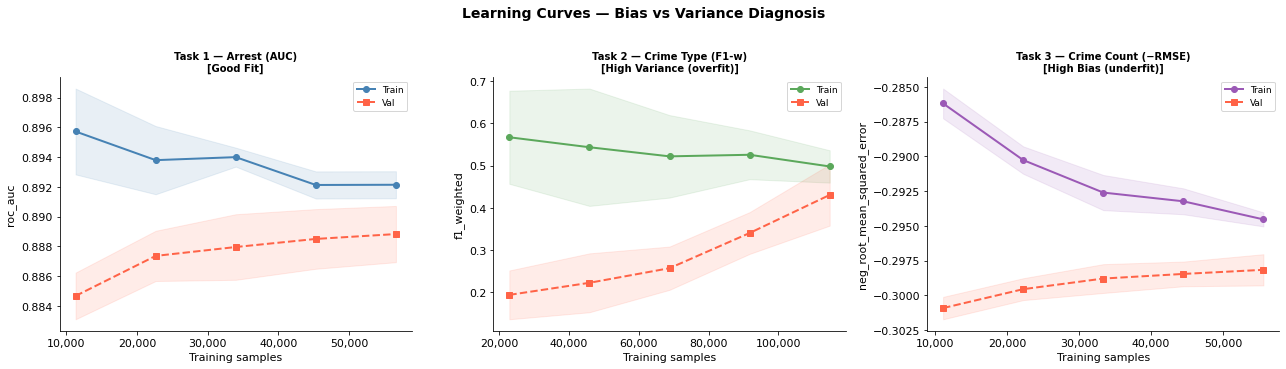

  Diagnoses → Task1: Good Fit  |  Task2: High Variance (overfit)  |  Task3: High Bias (underfit)


In [11]:
def plot_learning_curve(model, X, y, scoring, title, color, ax, cv=3):  
    train_sizes = np.linspace(0.2, 1.0, 5)  
    sizes, tr_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=train_sizes,
        cv=3, scoring=scoring,
        n_jobs=1, random_state=RANDOM_STATE
    )
    tr_mean  = tr_scores.mean(axis=1)
    tr_std   = tr_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(sizes, tr_mean,  'o-', color=color,    label='Train', linewidth=2)
    ax.plot(sizes, val_mean, 's--', color='tomato', label='Val',   linewidth=2)
    ax.fill_between(sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='tomato')

    gap = tr_mean[-1] - val_mean[-1]
    diagnosis = 'High Variance (overfit)' if gap > 0.05 else \
                'High Bias (underfit)'    if val_mean[-1] < 0.6 else 'Good Fit'

    ax.set_title(f'{title}\n[{diagnosis}]', fontweight='bold', fontsize=10)
    ax.set_xlabel('Training samples')
    ax.set_ylabel(scoring)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    return diagnosis


print('Plotting learning curves (this may take a few minutes)...')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

d1 = plot_learning_curve(best_m1, X_tr1, y_tr1, 'roc_auc',
                          'Task 1 — Arrest (AUC)', 'steelblue', axes[0])
print('  Task 1 done ✅')

d2 = plot_learning_curve(best_m2, X_tr2, y_tr2, 'f1_weighted',
                          'Task 2 — Crime Type (F1-w)', '#5ba85b', axes[1])
print('  Task 2 done ✅')

d3 = plot_learning_curve(best_m3, X_tr3, np.log1p(y_tr3),
                          'neg_root_mean_squared_error',
                          'Task 3 — Crime Count (−RMSE)', '#9b59b6', axes[2])
print('  Task 3 done ✅')

plt.suptitle('Learning Curves — Bias vs Variance Diagnosis',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/06_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Diagnoses → Task1: {d1}  |  Task2: {d2}  |  Task3: {d3}')

---
## 7. Error Analysis
Understand **where** each model fails.

In [12]:
# ── Task 1: False Positives vs False Negatives by feature ─────
y_pred1 = best_m1.predict(X_te1)
errors1 = pd.DataFrame(X_te1, columns=feat1)
errors1['y_true']  = y_te1
errors1['y_pred']  = y_pred1
errors1['correct'] = (y_te1 == y_pred1)
errors1['error_type'] = np.where(
    (y_te1 == 1) & (y_pred1 == 0), 'False Negative',
    np.where((y_te1 == 0) & (y_pred1 == 1), 'False Positive', 'Correct')
)

err_summary1 = errors1['error_type'].value_counts()
print('Task 1 Error Breakdown:')
print(err_summary1.to_string())
print(f'  Overall accuracy: {errors1["correct"].mean()*100:.2f}%')

Task 1 Error Breakdown:
Correct           14322
False Negative     3014
False Positive      664
  Overall accuracy: 79.57%


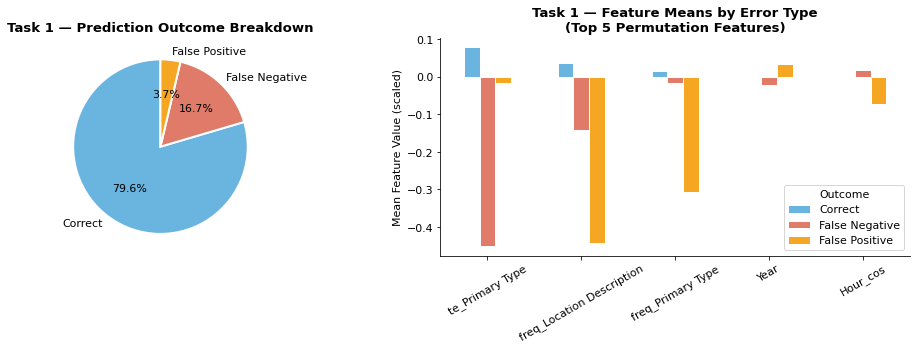

In [13]:
# ── Error type distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie of error types
colors_err = {'Correct': '#6ab4e0', 'False Negative': '#e07b6a', 'False Positive': '#f5a623'}
axes[0].pie(
    err_summary1.values,
    labels=err_summary1.index,
    autopct='%1.1f%%',
    colors=[colors_err[k] for k in err_summary1.index],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    startangle=90
)
axes[0].set_title('Task 1 — Prediction Outcome Breakdown', fontweight='bold')

# Feature mean by error type for top features
top_feat_err = perm1['feature'].head(5).tolist()
err_means = errors1.groupby('error_type')[top_feat_err].mean().T
err_means.plot.bar(ax=axes[1], edgecolor='white',
                   color=['#6ab4e0', '#e07b6a', '#f5a623'][:len(err_means.columns)])
axes[1].set_title('Task 1 — Feature Means by Error Type\n(Top 5 Permutation Features)',
                  fontweight='bold')
axes[1].set_ylabel('Mean Feature Value (scaled)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/06_task1_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

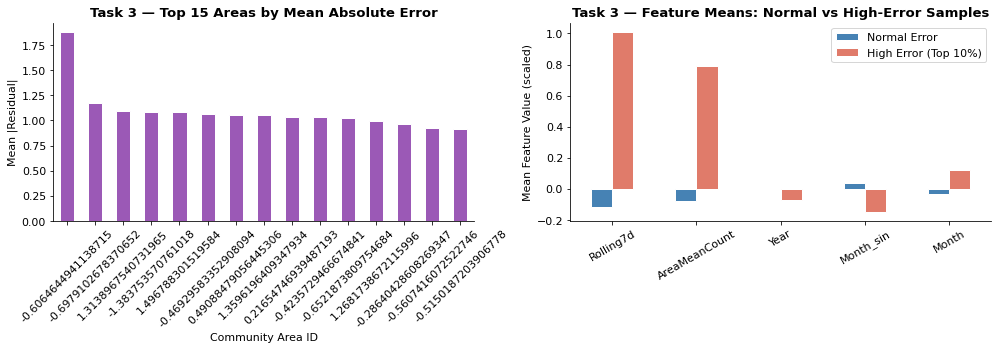

High-error threshold (90th pct): |residual| >= 1.70


In [14]:
# ── Task 3: Large residual analysis ───────────────────────────
y_pred3 = np.expm1(best_m3.predict(X_te3))
residuals3 = y_te3.astype(float) - y_pred3
abs_resid   = np.abs(residuals3)

# Identify high-error samples
threshold = np.percentile(abs_resid, 90)
high_err_idx = abs_resid >= threshold

errors3 = pd.DataFrame(X_te3, columns=feat3)
errors3['y_true']    = y_te3
errors3['y_pred']    = y_pred3
errors3['residual']  = residuals3
errors3['abs_resid'] = abs_resid
errors3['high_err']  = high_err_idx

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual by community area (first feature)
if 'Community Area' in feat3:
    area_resid = errors3.groupby('Community Area')['abs_resid'].mean().sort_values(ascending=False).head(15)
    area_resid.plot.bar(ax=axes[0], color='#9b59b6', edgecolor='white')
    axes[0].set_title('Task 3 — Top 15 Areas by Mean Absolute Error', fontweight='bold')
    axes[0].set_xlabel('Community Area ID')
    axes[0].set_ylabel('Mean |Residual|')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].hist(residuals3, bins=50, color='#9b59b6', edgecolor='none')
    axes[0].set_title('Task 3 — Residual Distribution', fontweight='bold')

# High-error vs normal error feature comparison
top_feat3 = perm3['feature'].head(5).tolist()
comp = errors3.groupby('high_err')[top_feat3].mean().T
comp.columns = ['Normal Error', 'High Error (Top 10%)']
comp.plot.bar(ax=axes[1], color=['steelblue', '#e07b6a'], edgecolor='white')
axes[1].set_title('Task 3 — Feature Means: Normal vs High-Error Samples', fontweight='bold')
axes[1].set_ylabel('Mean Feature Value (scaled)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/06_task3_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'High-error threshold (90th pct): |residual| >= {threshold:.2f}')

---
## 8. Feature Importance Consensus
Which features matter consistently across tree importance **and** permutation importance?

In [15]:
def consensus_importance(model, feature_names, perm_df, top_n=10):
    """Rank features by average rank across tree + permutation importance."""
    if not hasattr(model, 'feature_importances_'):
        return perm_df[['feature','mean']].head(top_n)

    tree_imp = pd.Series(model.feature_importances_, index=feature_names)
    tree_rank = tree_imp.rank(ascending=False)

    perm_imp  = perm_df.set_index('feature')['mean']
    perm_rank = perm_imp.rank(ascending=False)

    combined = pd.DataFrame({'tree_rank': tree_rank, 'perm_rank': perm_rank})
    combined = combined.dropna()
    combined['avg_rank'] = combined.mean(axis=1)
    return combined.sort_values('avg_rank').head(top_n)


print('\n📌 Feature Importance Consensus — Task 1 (Arrest Prediction)')
c1 = consensus_importance(best_m1, feat1, perm1)
print(c1.to_string())

print('\n📌 Feature Importance Consensus — Task 2 (Crime Type)')
c2 = consensus_importance(best_m2, feat2, perm2)
print(c2.to_string())

print('\n📌 Feature Importance Consensus — Task 3 (Crime Count)')
c3 = consensus_importance(best_m3, feat3, perm3)
print(c3.to_string())


📌 Feature Importance Consensus — Task 1 (Arrest Prediction)
                      feature      mean
16            te_Primary Type  0.351002
15  freq_Location Description  0.053292
14          freq_Primary Type  0.011166
5                        Year  0.002742
9                    Hour_cos  0.001345
11                  Month_cos  0.000545
1                        Hour  0.000430
7                     IsNight  0.000279
3                       Month  0.000155
8                    Hour_sin  0.000153

📌 Feature Importance Consensus — Task 2 (Crime Type)
                      feature      mean
15  freq_Location Description  0.184859
1                   ArrestInt  0.136903
10                   Hour_cos  0.014268
9                    Hour_sin  0.011047
2                        Hour  0.008250
6                        Year  0.007735
13              DayOfWeek_sin  0.004778
4                       Month  0.004689
3                   DayOfWeek  0.004175
11                  Month_sin  0.003229

📌 Fe

---
## 9. Final Pipeline Report

In [16]:
# Re-compute test scores for final report
y_pred_t1 = best_m1.predict(X_te1)
y_prob_t1 = best_m1.predict_proba(X_te1)[:, 1]
t1_auc    = roc_auc_score(y_te1, y_prob_t1)
t1_f1     = f1_score(y_te1, y_pred_t1, average='weighted')
t1_acc    = accuracy_score(y_te1, y_pred_t1)

y_pred_t2 = best_m2.predict(X_te2)
t2_f1_w   = f1_score(y_te2, y_pred_t2, average='weighted')
t2_acc    = accuracy_score(y_te2, y_pred_t2)

y_pred_t3 = np.expm1(best_m3.predict(X_te3))
t3_rmse   = np.sqrt(mean_squared_error(y_te3, y_pred_t3))
t3_r2     = r2_score(y_te3, y_pred_t3)

report = {
    'pipeline': 'Chicago Crime ML Pipeline',
    'notebooks': [
        '01_data_loading_sampling',
        '02_feature_engineering',
        '03_preprocessing',
        '04_model_training',
        '05_evaluation_comparison',
        '06_feature_importance_report'
    ],
    'tasks': {
        'task1': {
            'description'  : 'Arrest Prediction (Binary Classification)',
            'best_model'   : train_summary['task1']['best_model'],
            'test_auc'     : round(float(t1_auc), 4),
            'test_f1'      : round(float(t1_f1), 4),
            'test_accuracy': round(float(t1_acc), 4),
            'top_features' : c1.index.tolist()
        },
        'task2': {
            'description'  : 'Crime Type Prediction (Multi-class Classification)',
            'best_model'   : train_summary['task2']['best_model'],
            'test_f1_w'    : round(float(t2_f1_w), 4),
            'test_accuracy': round(float(t2_acc), 4),
            'n_classes'    : len(class_names),
            'top_features' : c2.index.tolist()
        },
        'task3': {
            'description' : 'Crime Count per Area (Regression)',
            'best_model'  : train_summary['task3']['best_model'],
            'test_rmse'   : round(float(t3_rmse), 4),
            'test_r2'     : round(float(t3_r2), 4),
            'top_features': c3.index.tolist()
        }
    }
}

with open(f'{DATA_DIR}/06_final_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('✅ Final report saved → ml_data/06_final_report.json')

✅ Final report saved → ml_data/06_final_report.json


In [19]:
LINE  = '=' * 72
SEP   = '-' * 72

print(LINE)
print('         CHICAGO CRIME ML PIPELINE — FINAL REPORT')
print(LINE)
print()
print('  Pipeline Notebooks:')
for nb in report['notebooks']:
    print(f'     {nb}.ipynb')

print()
print(SEP)
print('  TASK 1 — Arrest Prediction (Binary Classification)')
print(SEP)
t = report['tasks']['task1']
print(f"  Best Model        : {t['best_model']}")
print(f"  Test AUC          : {t['test_auc']}")
print(f"  Test F1 (weighted): {t['test_f1']}")
print(f"  Test Accuracy     : {t['test_accuracy']}")
print(f"  Top Features      : {', '.join(str(f) for f in t['top_features'][:5])}")

print()
print(SEP)
print('  TASK 2 — Crime Type Prediction (Multi-class)')
print(SEP)
t = report['tasks']['task2']
print(f"  Best Model        : {t['best_model']}")
print(f"  Classes           : {t['n_classes']} crime types")
print(f"  Test F1 (weighted): {t['test_f1_w']}")
print(f"  Test Accuracy     : {t['test_accuracy']}")
print(f"  Top Features      : {', '.join(str(f) for f in t['top_features'][:5])}")

print()
print(SEP)
print('  TASK 3 — Crime Count per Area (Regression)')
print(SEP)
t = report['tasks']['task3']
print(f"  Best Model        : {t['best_model']}")
print(f"  Test RMSE         : {t['test_rmse']}")
print(f"  Test R²           : {t['test_r2']}")
print(f"  Top Features      : {', '.join(str(f) for f in t['top_features'][:5])}")

print()
print(SEP)
print('  OUTPUTS GENERATED')
print(SEP)
outputs = [
    'ml_data/task1_arrest_prediction.csv',
    'ml_data/task2_crime_type_prediction.csv',
    'ml_data/task3_crime_count_per_area.csv',
    'ml_data/task1_engineered.csv  |  task2_engineered.csv  |  task3_engineered.csv',
    'ml_data/taskN_preprocessed.npz  |  taskN_scaler.pkl  |  taskN_meta.json',
    'ml_models/task1_best_model.pkl  |  task2_best_model.pkl  |  task3_best_model.pkl',
    'ml_models/training_summary.json',
    'ml_data/05_scorecard.csv',
    'ml_data/06_final_report.json',
    '10 × chart PNGs across notebooks 01–06',
]
for o in outputs:
    print(f'   {o}')

print()
print(LINE)
print('   PIPELINE COMPLETE')
print(LINE)

         CHICAGO CRIME ML PIPELINE — FINAL REPORT

  Pipeline Notebooks:
     01_data_loading_sampling.ipynb
     02_feature_engineering.ipynb
     03_preprocessing.ipynb
     04_model_training.ipynb
     05_evaluation_comparison.ipynb
     06_feature_importance_report.ipynb

------------------------------------------------------------------------
  TASK 1 — Arrest Prediction (Binary Classification)
------------------------------------------------------------------------
  Best Model        : Gradient Boosting
  Test AUC          : 0.8852
  Test F1 (weighted): 0.7918
  Test Accuracy     : 0.7957
  Top Features      : 16, 15, 14, 5, 9

------------------------------------------------------------------------
  TASK 2 — Crime Type Prediction (Multi-class)
------------------------------------------------------------------------
  Best Model        : Gradient Boosting
  Classes           : 10 crime types
  Test F1 (weighted): 0.4217
  Test Accuracy     : 0.4614
  Top Features      : 15, 1, 

In [21]:
for name, model in [('Task 1', best_m1), ('Task 2', best_m2), ('Task 3', best_m3)]:
    print(f'\n{"="*50}')
    print(f'{name}: {type(model).__name__}')
    print(f'  has feature_importances_ : {hasattr(model, "feature_importances_")}')
    print(f'  has coef_                : {hasattr(model, "coef_")}')
    print(f'  has named_steps          : {hasattr(model, "named_steps")}')
    if hasattr(model, 'named_steps'):
        for step_name, step in model.named_steps.items():
            print(f'  Step [{step_name}]: {type(step).__name__}')
            print(f'    has feature_importances_ : {hasattr(step, "feature_importances_")}')
            print(f'    has coef_                : {hasattr(step, "coef_")}')
    print(f'  All attrs with importance/coef: {[a for a in dir(model) if "import" in a.lower() or "coef" in a.lower()]}')


Task 1: HistGradientBoostingClassifier
  has feature_importances_ : False
  has coef_                : False
  has named_steps          : False
  All attrs with importance/coef: []

Task 2: HistGradientBoostingClassifier
  has feature_importances_ : False
  has coef_                : False
  has named_steps          : False
  All attrs with importance/coef: []

Task 3: HistGradientBoostingRegressor
  has feature_importances_ : False
  has coef_                : False
  has named_steps          : False
  All attrs with importance/coef: []
